In [124]:
import pandas as pd
driver_features = pd.read_csv('./data/driver_features.csv')
n_driver = len(driver_features)

In [125]:
import pandas as pd
import numpy as np

# 读取数据
race_data = pd.read_csv('data/f1_multi_season_results.csv')  # 你的比赛数据
teams_info = pd.read_csv('data/teams_info.csv')
driver_features = pd.read_csv('data/driver_features.csv')

# 1. 添加 TrackType（根据赛道名称）
track_types = {
    'Australia': 'balanced', 'China': 'high_speed', 'Japan': 'technical',
    'Bahrain': 'high_speed', 'Saudi Arabia': 'high_speed', 'Miami': 'high_speed',
    'Emilia Romagna': 'technical', 'Monaco': 'technical', 'Spain': 'balanced',
    'Canada': 'balanced', 'Austria': 'technical', 'Great Britain': 'balanced',
    'Belgium': 'high_speed', 'Hungary': 'technical', 'Netherlands': 'technical',
    'Italy': 'high_speed', 'Azerbaijan': 'high_speed', 'Singapore': 'technical',
    'United States': 'balanced', 'Mexico': 'balanced', 'Brazil': 'balanced',
    'Las Vegas': 'high_speed', 'Qatar': 'high_speed', 'Abu Dhabi': 'balanced',
}

if 'TrackType' not in race_data.columns:
    race_data['TrackType'] = race_data['Race'].map(track_types)

# 2. 添加 TrackTypeIdx
track_type_map = {'high_speed': 0, 'balanced': 1, 'technical': 2}
race_data['TrackTypeIdx'] = race_data['TrackType'].map(track_type_map)

# 3. 从 teams_info 添加 TierCode
# 创建车队到Tier的映射
team_tier_map = dict(zip(teams_info['Team'], teams_info['Tier']))
race_data['TierCode'] = race_data['Team'].map(team_tier_map)

# 4. 添加 DriverIdx（为每个车手分配唯一索引）
unique_drivers = race_data['Driver'].unique()
driver_to_idx = {driver: idx for idx, driver in enumerate(unique_drivers)}
race_data['DriverIdx'] = race_data['Driver'].map(driver_to_idx)
n_driver = len(unique_drivers)

# 5. 添加 EffectivePosition（未完赛=21）
race_data['EffectivePosition'] = race_data['Position'].copy()
race_data.loc[race_data['Status'] != 'Finished', 'EffectivePosition'] = 21.0

# 6. 从 driver_features 获取 Recent5Avg（如果存在）
# 创建车手到Recent5Avg的映射
driver_recent5_map = dict(zip(driver_features['Driver'], driver_features['Recent5Avg']))

# 但是我们需要动态计算每场比赛时的Recent5Avg，而不是使用全赛季的
# 所以还是按时间顺序计算
race_data = race_data.sort_values(['Driver', 'GlobalRound'])
race_data['Recent5Avg'] = race_data.groupby('Driver')['EffectivePosition'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
)
# 第一场比赛用车手的平均值填充（从driver_features获取）
driver_avg_map = dict(zip(driver_features['Driver'], driver_features['AvgPosition']))
race_data['Recent5Avg'] = race_data.apply(
    lambda row: driver_avg_map.get(row['Driver'], race_data['EffectivePosition'].mean()) 
    if pd.isna(row['Recent5Avg']) else row['Recent5Avg'],
    axis=1
)

# 7. 计算 CumDNFRate（累计未完赛率）
race_data['IsDNF'] = (race_data['Status'] != 'Finished').astype(int)
race_data['CumDNFRate'] = race_data.groupby('Driver')['IsDNF'].transform(
    lambda x: x.shift(1).expanding().mean()
)
# 第一场比赛用车手的DNFRate填充（从driver_features获取）
driver_dnf_map = dict(zip(driver_features['Driver'], driver_features['DNFRate']))
race_data['CumDNFRate'] = race_data.apply(
    lambda row: driver_dnf_map.get(row['Driver'], 0) 
    if pd.isna(row['CumDNFRate']) else row['CumDNFRate'],
    axis=1
)

# 8. 确保所有必要的列都存在
required_columns = [
    'Driver', 'Team', 'Race', 'TrackType', 'TrackTypeIdx', 
    'TierCode', 'DriverIdx', 'GridPosition', 'QualifyingPosition',
    'Position', 'EffectivePosition', 'Recent5Avg', 'CumDNFRate', 
    'Status', 'GlobalRound', 'Season'
]

# 保存处理后的数据
race_data.to_csv('data/f1_race_data_cleaned.csv', index=False)

print(f"处理完成！")
print(f"车手数量 (n_driver): {n_driver}")
print(f"总比赛场次: {len(race_data)}")
print(f"\n数据预览:")
print(race_data[['Driver', 'Team', 'Race', 'TierCode', 'TrackTypeIdx', 
                  'EffectivePosition', 'Recent5Avg', 'CumDNFRate']].head(10))

# 检查缺失值
print(f"\n缺失值检查:")
print(race_data[['TierCode', 'TrackTypeIdx', 'Recent5Avg', 'CumDNFRate']].isnull().sum())

# 输出车队tier分布
print(f"\n车队Tier分布:")
print(race_data.groupby(['Team', 'TierCode']).size().sort_values(ascending=False))

处理完成！
车手数量 (n_driver): 22
总比赛场次: 439

数据预览:
      Driver      Team            Race  TierCode  TrackTypeIdx  \
4    A ALBON  Williams       Australia         1             1   
26   A ALBON  Williams           China         1             0   
48   A ALBON  Williams           Japan         1             2   
71   A ALBON  Williams         Bahrain         1             0   
88   A ALBON  Williams    Saudi Arabia         1             0   
104  A ALBON  Williams           Miami         1             0   
124  A ALBON  Williams  Emilia Romagna         1             2   
148  A ALBON  Williams          Monaco         1             2   
178  A ALBON  Williams           Spain         1             1   
198  A ALBON  Williams          Canada         1             1   

     EffectivePosition  Recent5Avg  CumDNFRate  
4                  5.0    8.307692    0.409091  
26                 7.0    5.000000    0.000000  
48                 9.0    6.000000    0.000000  
71                12.0    7.00000

In [126]:
import pymc as pm

with pm.Model() as f1_final_model:

    # level 1 priori team
    mu_tier = [-12,-5,0]
    sigma_tier = 2
    beta_team = pm.Normal('beta_team',mu=mu_tier,sigma=sigma_tier,shape=3)
    # level 2 driver ability
    sigma_driver = pm.HalfNormal('sigma_driver',2.0)
    gamma_driver = pm.Normal('gamma_driver',mu =0,sigma = sigma_driver, shape = n_driver)
    # level 3 settings
    alpha = pm.Normal('alpha', mu=10.6, sigma=2)
    # delta_track = pm.Normal('delta_track', mu=0, sigma=3.5)
    eta_grid = pm.Normal('eta_grid', mu=0, sigma=0.5)
    epsilon_trend = pm.Normal('epsilon_trend', mu=0, sigma=3.5)
    zeta_dnf = pm.HalfNormal('zeta_dnf', 3.5)
    # sigma_race = pm.HalfNormal('sigma_race', 1.0) 

    # Track type effects (3 types: high_speed, balanced, technical)
    delta_track = pm.Normal('delta_track', mu=0, sigma=2, shape=3)
    sigma_race = pm.HalfNormal('sigma_race', 1.0)
    xi_quali = pm.Normal('xi_quali', mu=0, sigma=0.8)  

    track_type_map = {'high_speed': 0, 'balanced': 1, 'technical': 2}
    race_data['TrackTypeIdx'] = race_data['TrackType'].map(track_type_map)

    # likelyhood
    mu_position = (
        alpha +
        beta_team[race_data['TierCode'].values] +
        gamma_driver[race_data['DriverIdx'].values] +  # 使用 driver index!
        eta_grid * race_data['GridPosition'].values +
        # xi_quali * race_data['QualifyingPosition'].values +
        delta_track[race_data['TrackTypeIdx'].values] +  # Track type effect
        epsilon_trend * race_data['Recent5Avg'].values +
        zeta_dnf * race_data['CumDNFRate'].values
    )
    y_obs = pm.Normal(
        'y_obs', 
        mu=mu_position, 
        sigma=sigma_race,
        observed=race_data['EffectivePosition'].values  # 440 observations!
        # observed=race_data['QualifyingPosition'].values  # 440 observations!
    )

In [127]:
with f1_final_model:
    trace_test = pm.sample(4000, tune=2000, random_seed=2024, chains=4,cores=4, target_accept=0.998,progressbar=True)
    trace_test.to_netcdf('./model/f1_trace.nc')
    print("✓ Trace saved to './model/f1_trace.nc'")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_team, sigma_driver, gamma_driver, alpha, eta_grid, epsilon_trend, zeta_dnf, delta_track, sigma_race, xi_quali]


Output()

Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 62 seconds.


✓ Trace saved to './model/f1_trace.nc'


In [128]:
import arviz as az
import numpy as np

# 加载 trace
trace = az.from_netcdf('./model/f1_trace.nc')

print("="*60)
print("QUICK DIAGNOSTICS")
print("="*60)

# 1. R-hat (修正版本)
rhat = az.rhat(trace)
# 提取所有变量的最大 R-hat
max_rhat_values = []
for var in rhat.data_vars:
    max_rhat_values.append(float(rhat[var].max().values))
max_rhat = max(max_rhat_values)

print(f"\nMax R-hat: {max_rhat:.4f}")

if max_rhat > 1.01:
    print("⚠️ WARNING: Chains have NOT converged!")
else:
    print("✓ Chains converged")

# 2. ESS (修正版本)
ess = az.ess(trace)
min_ess_values = []
for var in ess.data_vars:
    min_ess_values.append(float(ess[var].min().values))
min_ess = min(min_ess_values)

print(f"Min ESS: {min_ess:.0f}")

if min_ess < 400:
    print("⚠️ WARNING: Low ESS")
else:
    print("✓ Sufficient ESS")

# 3. Divergences (修正版本)
divergences = int(trace.sample_stats.diverging.sum().values)
print(f"Divergences: {divergences}")

if divergences > 0:
    print(f"⚠️ {divergences} divergent transitions")
else:
    print("✓ No divergences")

# 总结
print("\n" + "="*60)
if max_rhat < 1.01 and min_ess > 400:
    print("✓ MODEL IS USABLE (despite divergence)")
    print("You can proceed with analysis!")
elif max_rhat > 1.01:
    print("❌ NEED TO RESAMPLE with higher target_accept")
elif min_ess < 100:
    print("❌ NEED MORE SAMPLES")
else:
    print("⚠️ MODEL IS OKAY but could be better")

# 运行这个来确认统计有效性
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error
import pymc as pm

race_data = pd.read_csv('./data/f1_race_data_cleaned.csv')

with f1_final_model:
    posterior_pred = pm.sample_posterior_predictive(trace, random_seed=42)

y_pred = posterior_pred.posterior_predictive['y_obs'].values
y_obs = race_data['EffectivePosition'].values

y_pred_mean = y_pred.mean(axis=(0, 1))

r2 = r2_score(y_obs, y_pred_mean)
mae = mean_absolute_error(y_obs, y_pred_mean)

print(f"R² = {r2:.3f}")
print(f"MAE = {mae:.2f} positions")

QUICK DIAGNOSTICS

Max R-hat: 1.0059
✓ Chains converged
Min ESS: 458
✓ Sufficient ESS
Divergences: 0
✓ No divergences

✓ MODEL IS USABLE (despite divergence)
You can proceed with analysis!


Sampling: [y_obs]


Output()

R² = 0.489
MAE = 4.17 positions


In [129]:
import pandas as pd
import numpy as np

# ===========================
# 最简单的方案：直接使用现有数据
# ===========================

# 加载数据
race_data = pd.read_csv('data/f1_race_data_cleaned.csv')
teams_info = pd.read_csv('data/teams_info.csv')
driver_features = pd.read_csv('data/driver_features.csv')

# 创建映射
unique_drivers = race_data['Driver'].unique()
driver_to_idx = {driver: idx for idx, driver in enumerate(unique_drivers)}
team_tier_map = dict(zip(teams_info['Team'], teams_info['Tier']))

# 从driver_features创建映射
driver_recent5_map = dict(zip(driver_features['Driver'], driver_features['Recent5Avg']))
driver_dnf_map = dict(zip(driver_features['Driver'], driver_features['DNFRate']))

# ===========================
# 卡塔尔站数据
# ===========================

qatar_data = {
    'Driver': ['O PIASTRI', 'L NORRIS', 'M VERSTAPPEN', 'G RUSSELL', 'K ANTONELLI',
               'I HADJAR', 'C SAINZ', 'F ALONSO', 'P GASLY', 'C LECLERC',
               'N HULKENBERG', 'L LAWSON', 'O BEARMAN', 'G BORTOLETO', 'A ALBON',
               'Y TSUNODA', 'E OCON', 'L HAMILTON', 'L STROLL', 'F COLAPINTO'],
    
    'QualifyingPosition': list(range(1, 21)),
    'GridPosition': list(range(1, 21)),
    
    'Team': ['McLaren', 'McLaren', 'Red Bull Racing', 'Mercedes', 'Mercedes',
             'Racing Bulls', 'Williams', 'Aston Martin', 'Alpine', 'Ferrari',
             'Kick Sauber', 'Racing Bulls', 'Haas F1 Team', 'Kick Sauber', 'Williams',
             'Red Bull Racing', 'Haas F1 Team', 'Ferrari', 'Aston Martin', 'Alpine'],
    
    'TrackType': ['high_speed'] * 20,
    'GlobalRound': [1] * 20,
}

qatar_df = pd.DataFrame(qatar_data)

# ===========================
# 补齐特征
# ===========================

track_type_map = {'high_speed': 0, 'balanced': 1, 'technical': 2}

qatar_df['TrackTypeIdx'] = qatar_df['TrackType'].map(track_type_map)
qatar_df['TierCode'] = qatar_df['Team'].map(team_tier_map)
qatar_df['DriverIdx'] = qatar_df['Driver'].map(driver_to_idx)

# 直接从driver_features获取
qatar_df['Recent5Avg'] = qatar_df['Driver'].map(driver_recent5_map)
qatar_df['CumDNFRate'] = qatar_df['Driver'].map(driver_dnf_map)
qatar_df.to_csv('./data/qatar_ready.csv')

gamma_driver shape: (4, 4000, 22)
模型中的车手数: 22

预测结果（含众数）：

      Driver      Mean    Median      Mode
    L NORRIS  3.994059  2.568146  1.057057
   O PIASTRI  4.068410  2.706109  1.057057
   G RUSSELL  5.086000  4.260360  1.095095
 K ANTONELLI  5.951225  5.410311  1.114114
M VERSTAPPEN  6.129298  5.565326  1.133133
   C LECLERC  7.685962  7.452663  1.190190
     C SAINZ  8.748802  8.567937  8.284284
    I HADJAR 10.268564 10.195888  9.805806
    F ALONSO 11.041231 11.114666 11.251251
  L HAMILTON 12.006009 12.109711 11.992993

✅ 完成


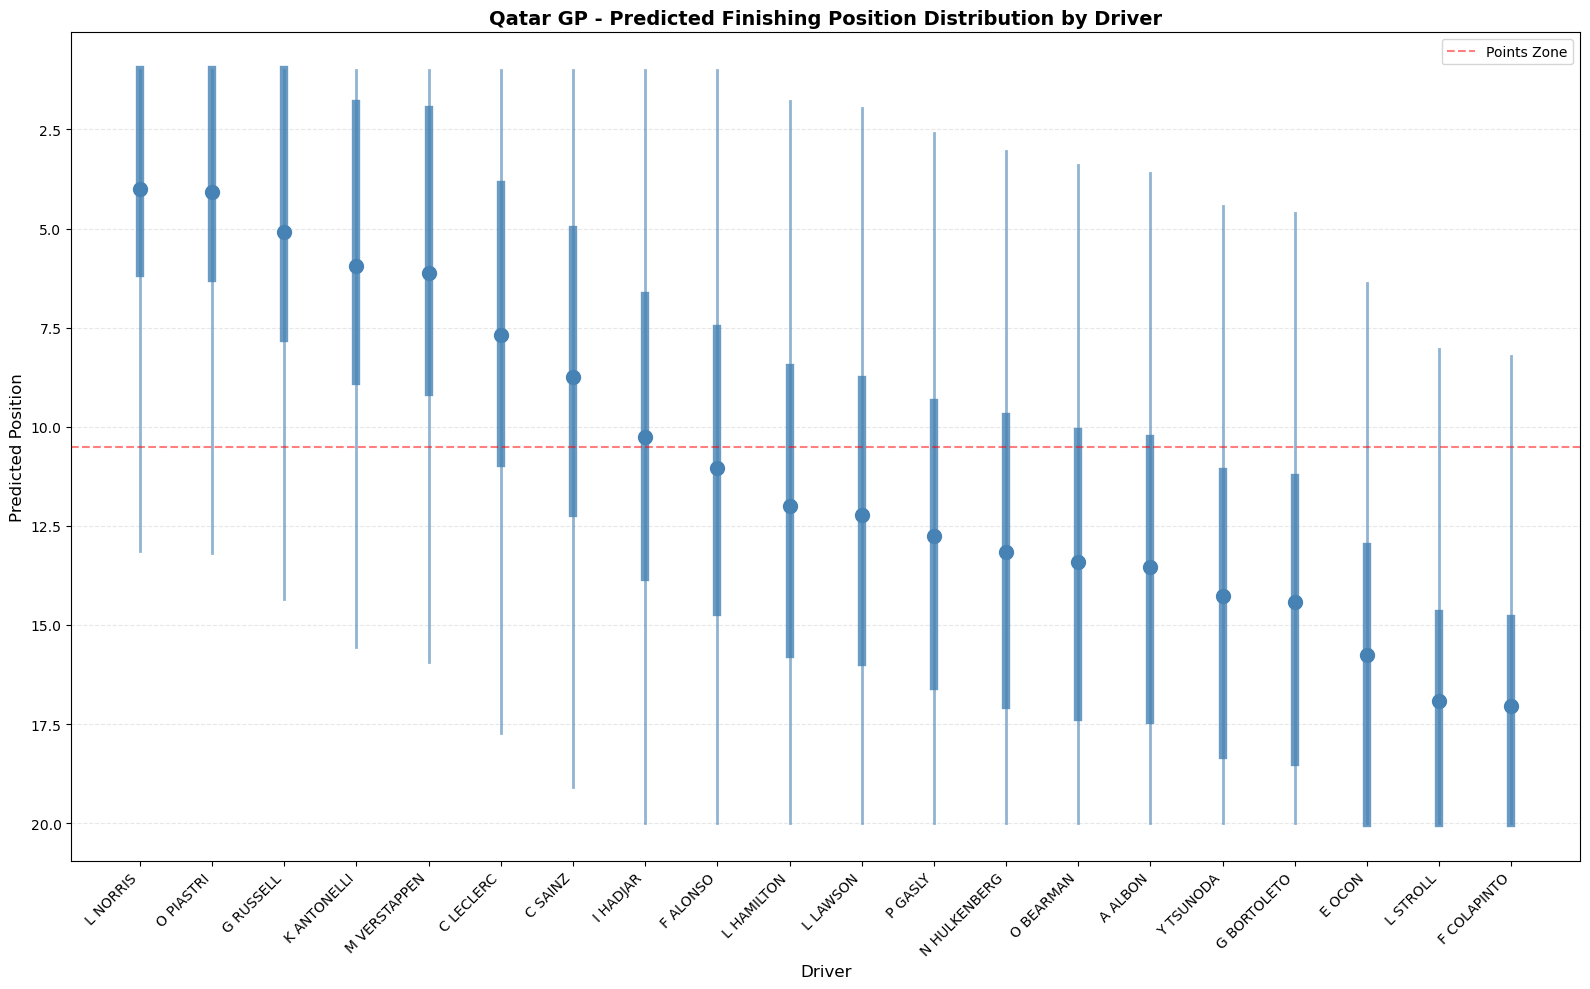

In [130]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from scipy import stats

# 加载数据和模型
qatar_df = pd.read_csv('./data/qatar_ready.csv')
trace = az.from_netcdf('./model/f1_trace.nc')

print("gamma_driver shape:", trace.posterior['gamma_driver'].shape)
n_drivers_in_model = trace.posterior['gamma_driver'].shape[-1]
print(f"模型中的车手数: {n_drivers_in_model}")

# 提取后验参数
posterior = trace.posterior
alpha = posterior['alpha'].values.flatten()
beta_team = posterior['beta_team'].values.reshape(-1, 3)
gamma_driver = posterior['gamma_driver'].values.reshape(-1, n_drivers_in_model)
eta_grid = posterior['eta_grid'].values.flatten()
delta_track = posterior['delta_track'].values.reshape(-1, 3)
epsilon_trend = posterior['epsilon_trend'].values.flatten()
zeta_dnf = posterior['zeta_dnf'].values.flatten()
sigma_race = posterior['sigma_race'].values.flatten()

# 预测
results = []

for idx, row in qatar_df.iterrows():
    driver_idx = int(row['DriverIdx'])
    
    if driver_idx >= n_drivers_in_model:
        print(f"警告: {row['Driver']} 的 DriverIdx={driver_idx} 超出模型范围")
        continue
    
    mu = (
        alpha +
        beta_team[:, int(row['TierCode'])] +
        gamma_driver[:, driver_idx] +
        eta_grid * row['GridPosition'] +
        delta_track[:, int(row['TrackTypeIdx'])] +
        epsilon_trend * row['Recent5Avg'] +
        zeta_dnf * row['CumDNFRate']
    )
    
    positions = np.random.normal(mu, sigma_race)
    positions = np.clip(positions, 1, 20)
    
    # 计算众数（使用核密度估计）
    kde = stats.gaussian_kde(positions)
    x_range = np.linspace(1, 20, 1000)
    density = kde(x_range)
    mode = x_range[np.argmax(density)]
    
    results.append({
        'Driver': row['Driver'],
        'Mean': positions.mean(),
        'Median': np.median(positions),
        'Mode': mode,  # 众数
        'Q25': np.percentile(positions, 25),
        'Q75': np.percentile(positions, 75),
        'CI_2.5': np.percentile(positions, 2.5),
        'CI_97.5': np.percentile(positions, 97.5)
    })

results_df = pd.DataFrame(results).sort_values('Mean')
results_df.to_csv('./data/qatar_predict.csv', index=False)

print("\n预测结果（含众数）：\n")
print(results_df[['Driver', 'Mean', 'Median', 'Mode']].head(10).to_string(index=False))

# 绘图
fig, ax = plt.subplots(figsize=(16, 10))

drivers = results_df['Driver'].values
means = results_df['Mean'].values
q25 = results_df['Q25'].values
q75 = results_df['Q75'].values
ci_lower = results_df['CI_2.5'].values
ci_upper = results_df['CI_97.5'].values

x_pos = np.arange(len(drivers))

for i in range(len(drivers)):
    ax.plot([x_pos[i], x_pos[i]], [ci_lower[i], ci_upper[i]], 
            color='steelblue', linewidth=2, alpha=0.6)
    ax.plot([x_pos[i], x_pos[i]], [q25[i], q75[i]], 
            color='steelblue', linewidth=6, alpha=0.8)

ax.scatter(x_pos, means, color='steelblue', s=100, zorder=3)
ax.set_xticks(x_pos)
ax.set_xticklabels(drivers, rotation=45, ha='right')
ax.set_xlabel('Driver', fontsize=12)
ax.set_ylabel('Predicted Position', fontsize=12)
ax.set_title('Qatar GP - Predicted Finishing Position Distribution by Driver', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=10.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Points Zone')
ax.legend()

plt.tight_layout()
plt.savefig('qatar_position_distribution.png', dpi=300, bbox_inches='tight')
print("\n✅ 完成")
plt.show()

In [131]:
import pandas as pd

# 完整实际结果
actual_results = {
    'Driver': ['M VERSTAPPEN', 'O PIASTRI', 'C SAINZ', 'L NORRIS', 'K ANTONELLI',
               'G RUSSELL', 'F ALONSO', 'C LECLERC', 'L LAWSON', 'Y TSUNODA',
               'A ALBON', 'L HAMILTON', 'G BORTOLETO', 'F COLAPINTO', 'E OCON',
               'P GASLY', 'L STROLL', 'I HADJAR', 'O BEARMAN', 'N HULKENBERG'],
    'ActualPosition': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
}
actual_df = pd.DataFrame(actual_results)


# 从CSV读取预测结果（无排名约束版本）
predicted_df = pd.read_csv('./data/qatar_predict.csv')

# 按PredictedPosition排序生成排名
predicted_df = predicted_df.sort_values('Mode').reset_index(drop=True)
predicted_df['PredictedRank'] = range(1, len(predicted_df) + 1)

# 合并
comparison = actual_df.merge(predicted_df, on='Driver')
comparison['RankDiff'] = abs(comparison['ActualPosition'] - comparison['PredictedRank'])

print("=" * 80)
print("卡塔尔站预测准确性分析")
print("=" * 80)

# 详细对比
print("\n完整排名对比：\n")
print(comparison[['ActualPosition', 'Driver', 'PredictedRank', 'RankDiff']].to_string(index=False))

# 总体指标
print("\n" + "=" * 80)
print("总体准确性指标")
print("=" * 80)
print(f"平均排名误差: {comparison['RankDiff'].mean():.2f} 位")
print(f"中位数误差: {comparison['RankDiff'].median():.1f} 位")
print(f"最大误差: {comparison['RankDiff'].max():.0f} 位")

# 冠军预测
winner_actual = actual_df[actual_df['ActualPosition'] == 1]['Driver'].values[0]
winner_predicted = predicted_df[predicted_df['PredictedRank'] == 1]['Driver'].values[0]
winner_correct = winner_actual == winner_predicted

print("\n" + "=" * 80)
print("分段准确性")
print("=" * 80)

# P1 准确性
print(f"\n🏆 冠军预测: {'✓ 正确' if winner_correct else '✗ 错误'}")
print(f"   预测: {winner_predicted}")
print(f"   实际: {winner_actual}")

# 前3准确性
top3_actual = set(actual_df[actual_df['ActualPosition'] <= 3]['Driver'])
top3_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 3]['Driver'])
top3_correct = top3_actual & top3_predicted

print(f"\n🥇 领奖台(前3)准确性: {len(top3_correct)}/3 正确 ({len(top3_correct)/3*100:.0f}%)")
print(f"   预测: {sorted(top3_predicted)}")
print(f"   实际: {sorted(top3_actual)}")
print(f"   命中: {sorted(top3_correct)}")
print(f"   遗漏: {sorted(top3_actual - top3_predicted)}")

# 前5准确性
top5_actual = set(actual_df[actual_df['ActualPosition'] <= 5]['Driver'])
top5_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 5]['Driver'])
top5_correct = top5_actual & top5_predicted

print(f"\n🏁 前5准确性: {len(top5_correct)}/5 正确 ({len(top5_correct)/5*100:.0f}%)")
print(f"   预测: {sorted(top5_predicted)}")
print(f"   实际: {sorted(top5_actual)}")
print(f"   命中: {sorted(top5_correct)}")
print(f"   遗漏: {sorted(top5_actual - top5_predicted)}")

# 前10(积分区)准确性
top10_actual = set(actual_df[actual_df['ActualPosition'] <= 10]['Driver'])
top10_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 10]['Driver'])
top10_correct = top10_actual & top10_predicted

print(f"\n📊 积分区(前10)准确性: {len(top10_correct)}/10 正确 ({len(top10_correct)/10*100:.0f}%)")
print(f"   命中: {len(top10_correct)} 位车手")
print(f"   遗漏: {sorted(top10_actual - top10_predicted)}")

# 最大意外
print("\n" + "=" * 80)
print("预测偏差最大的车手")
print("=" * 80)
biggest_errors = comparison.nlargest(5, 'RankDiff')
for idx, row in biggest_errors.iterrows():
    direction = "表现优于预期" if row['ActualPosition'] < row['PredictedRank'] else "表现不及预期"
    print(f"{row['Driver']:20s} 实际P{row['ActualPosition']:2.0f} vs 预测P{row['PredictedRank']:2.0f} "
          f"(误差{row['RankDiff']:.0f}位) - {direction}")

print("\n" + "=" * 80)

卡塔尔站预测准确性分析

完整排名对比：

 ActualPosition       Driver  PredictedRank  RankDiff
              1 M VERSTAPPEN              5         4
              2    O PIASTRI              2         0
              3      C SAINZ              7         4
              4     L NORRIS              1         3
              5  K ANTONELLI              4         1
              6    G RUSSELL              3         3
              7     F ALONSO              9         2
              8    C LECLERC              6         2
              9     L LAWSON             12         3
             10    Y TSUNODA             16         6
             11      A ALBON             14         3
             12   L HAMILTON             10         2
             13  G BORTOLETO             17         4
             14  F COLAPINTO             20         6
             15       E OCON             18         3
             16      P GASLY             11         5
             17     L STROLL             19         2
      

In [152]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

qatar_df = pd.read_csv('data/qatar_ready.csv')
trace = az.from_netcdf('model/f1_trace.nc')

# 提取后验参数
posterior = trace.posterior
n_drivers_in_model = trace.posterior['gamma_driver'].shape[-1]

alpha = posterior['alpha'].values.flatten()
beta_team = posterior['beta_team'].values.reshape(-1, 3)
gamma_driver = posterior['gamma_driver'].values.reshape(-1, n_drivers_in_model)
eta_grid = posterior['eta_grid'].values.flatten()
delta_track = posterior['delta_track'].values.reshape(-1, 3)
epsilon_trend = posterior['epsilon_trend'].values.flatten()
zeta_dnf = posterior['zeta_dnf'].values.flatten()
sigma_race = posterior['sigma_race'].values.flatten()

n_samples = len(alpha)
n_simulations = 1000_00

# ===========================
# 蒙特卡洛模拟：生成完整排名
# ===========================

position_counts = np.zeros((len(qatar_df), 20))

for sim in range(n_simulations):
    sample_idx = np.random.randint(0, n_samples)
    
    predicted_positions = []
    for idx, row in qatar_df.iterrows():
        mu = (
            alpha[sample_idx] +
            beta_team[sample_idx, int(row['TierCode'])] +
            gamma_driver[sample_idx, int(row['DriverIdx'])] +
            eta_grid[sample_idx] * row['GridPosition'] +
            delta_track[sample_idx, int(row['TrackTypeIdx'])] +
            epsilon_trend[sample_idx] * row['Recent5Avg'] +
            zeta_dnf[sample_idx] * row['CumDNFRate']
        )
        
        pos = np.random.normal(mu, sigma_race[sample_idx])
        predicted_positions.append(pos)
    
    ranks = np.argsort(predicted_positions) + 1
    
    for driver_idx, rank in enumerate(ranks):
        if 1 <= rank <= 20:
            position_counts[driver_idx, rank - 1] += 1

position_probs = position_counts / n_simulations

# ===========================
# 输出结果
# ===========================

results = []
for idx, row in qatar_df.iterrows():
    probs = position_probs[idx]
    most_likely_pos = np.argmax(probs) + 1
    expected_pos = np.sum([(i+1) * probs[i] for i in range(20)])
    
    # 计算分位数
    cumsum = np.cumsum(probs)
    q25 = np.searchsorted(cumsum, 0.25) + 1
    q75 = np.searchsorted(cumsum, 0.75) + 1
    ci_lower = np.searchsorted(cumsum, 0.025) + 1
    ci_upper = np.searchsorted(cumsum, 0.975) + 1
    mode_pos = np.argmax(probs) + 1
    
    results.append({
        'Driver': row['Driver'],
        'ExpectedPosition': expected_pos,
        'MostLikelyPosition': most_likely_pos,
        'Mode':mode_pos,
        'P_Win': probs[0],
        'P_Podium': probs[:3].sum(),
        'P_Points': probs[:10].sum(),
        'Q25': q25,
        'Q75': q75,
        'CI_2.5': ci_lower,
        'CI_97.5': ci_upper
    })

# results_df = pd.DataFrame(results).sort_values('Mode')
# results_df = pd.DataFrame(results).sort_values(['Mode', 'ExpectedPosition'])
results_df = pd.DataFrame(results).sort_values(
    by=['MostLikelyPosition', 'ExpectedPosition', 'P_Win', 'Q25', 'CI_2.5'],
    ascending=[True, True, False, True, True]
)

print("\n卡塔尔站预测（考虑排名约束）：\n")
print(results_df[['Driver', 'ExpectedPosition', 'MostLikelyPosition', 
                  'P_Win', 'P_Podium', 'P_Points']].to_string(index=False))

results_df.to_csv('./data/qatar_predict_menka.csv', index=False)



卡塔尔站预测（考虑排名约束）：

      Driver  ExpectedPosition  MostLikelyPosition   P_Win  P_Podium  P_Points
M VERSTAPPEN           5.51703                   1 0.13942   0.39106   0.88680
   O PIASTRI           3.69467                   2 0.23334   0.58271   0.96744
    L NORRIS           4.65884                   2 0.17673   0.47262   0.92904
 K ANTONELLI           7.20094                   3 0.08340   0.26685   0.77942
   G RUSSELL           6.37390                   4 0.10770   0.32403   0.83500
     P GASLY          10.09380                   6 0.02861   0.10809   0.54633
   C LECLERC          10.72890                   6 0.02180   0.08431   0.48931
    F ALONSO           9.43515                   7 0.03813   0.13576   0.60436
    I HADJAR           8.00709                  10 0.06540   0.21456   0.72080
     C SAINZ           8.77304                  10 0.05004   0.17120   0.65901
    L LAWSON          11.77366                  11 0.01180   0.05194   0.39619
   O BEARMAN          12.23729    


✅ 完成


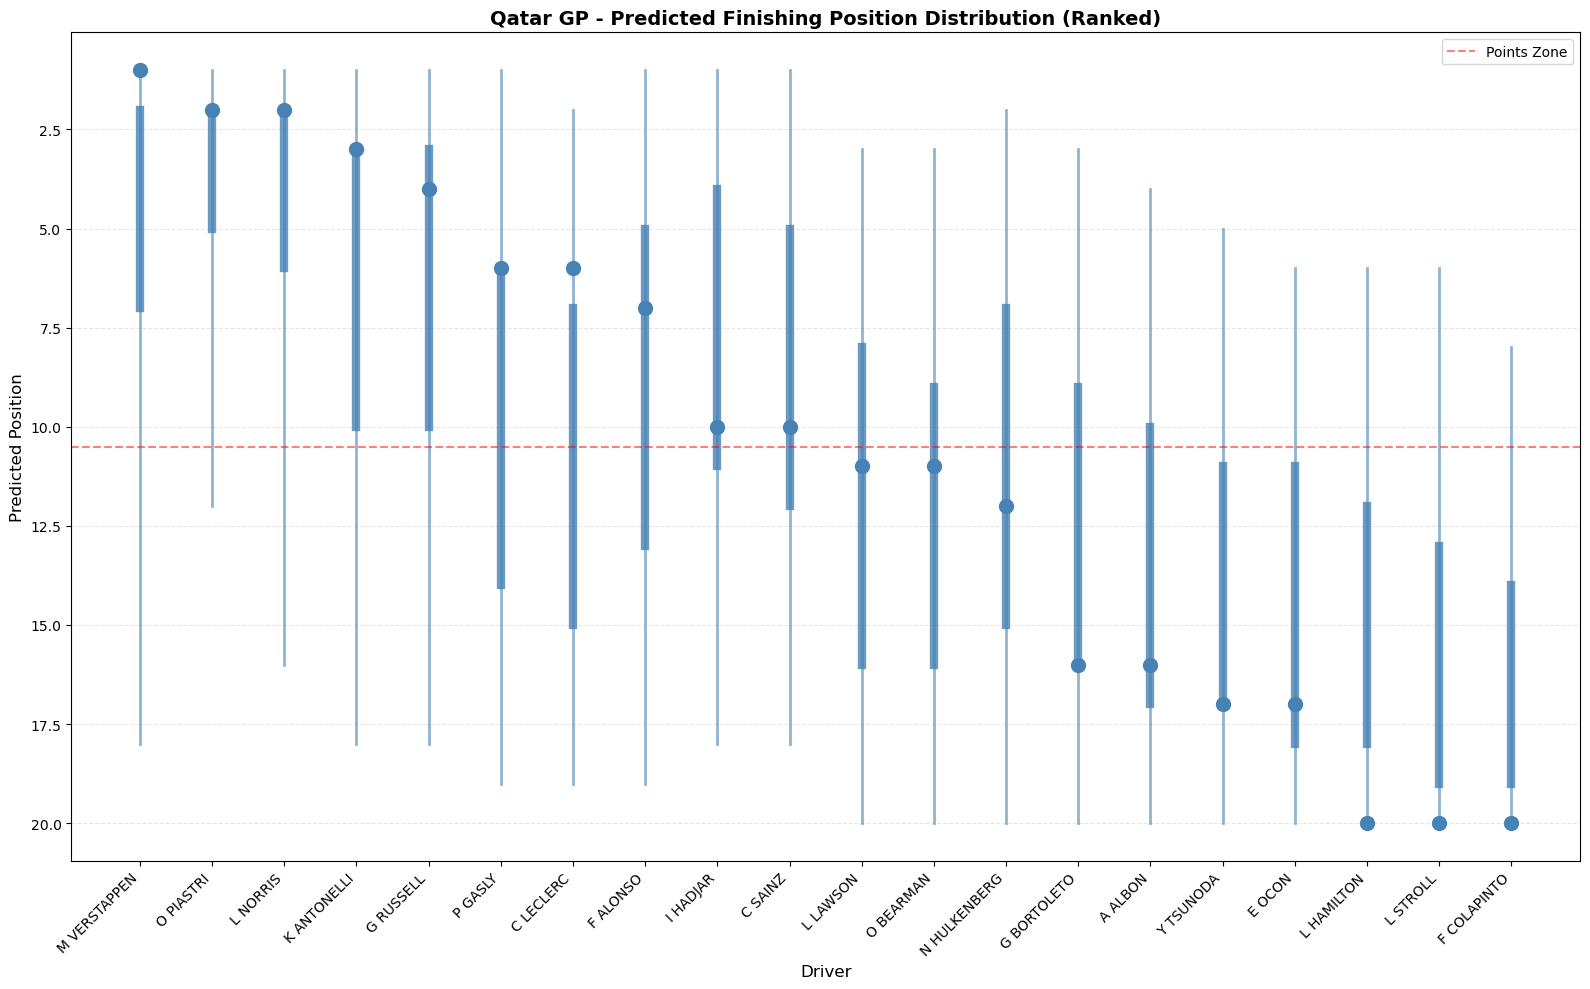

In [153]:
# ===========================
# 绘图
# ===========================

results_df=pd.read_csv('./data/qatar_predict_menka.csv')

fig, ax = plt.subplots(figsize=(16, 10))

drivers = results_df['Driver'].values
expected = results_df['Mode'].values
q25 = results_df['Q25'].values
q75 = results_df['Q75'].values
ci_lower = results_df['CI_2.5'].values
ci_upper = results_df['CI_97.5'].values

x_pos = np.arange(len(drivers))

for i in range(len(drivers)):
    ax.plot([x_pos[i], x_pos[i]], [ci_lower[i], ci_upper[i]], 
            color='steelblue', linewidth=2, alpha=0.6)
    ax.plot([x_pos[i], x_pos[i]], [q25[i], q75[i]], 
            color='steelblue', linewidth=6, alpha=0.8)

ax.scatter(x_pos, expected, color='steelblue', s=100, zorder=3)
ax.set_xticks(x_pos)
ax.set_xticklabels(drivers, rotation=45, ha='right')
ax.set_xlabel('Driver', fontsize=12)
ax.set_ylabel('Predicted Position', fontsize=12)
ax.set_title('Qatar GP - Predicted Finishing Position Distribution (Ranked)', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=10.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Points Zone')
ax.legend()

plt.tight_layout()
plt.savefig('qatar_position_distribution.png', dpi=300, bbox_inches='tight')
print("\n✅ 完成")
plt.show()

In [154]:
import pandas as pd

# 实际结果
actual_results = {
    'Driver': ['M VERSTAPPEN', 'O PIASTRI', 'C SAINZ', 'L NORRIS', 'K ANTONELLI',
               'G RUSSELL', 'F ALONSO', 'C LECLERC', 'L LAWSON', 'Y TSUNODA',
               'A ALBON', 'L HAMILTON', 'G BORTOLETO', 'F COLAPINTO', 'E OCON',
               'P GASLY', 'L STROLL', 'I HADJAR', 'O BEARMAN', 'N HULKENBERG'],
    'ActualPosition': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
}
actual_df = pd.DataFrame(actual_results)

# 从CSV读取预测结果
predicted_df = pd.read_csv('./data/qatar_predict_menka.csv')

# 使用ExpectedPosition作为预测排名
predicted_df = predicted_df.sort_values('Mode').reset_index(drop=True)
predicted_df['PredictedRank'] = range(1, len(predicted_df) + 1)

# 合并
comparison = actual_df.merge(predicted_df[['Driver', 'PredictedRank']], on='Driver')
comparison['RankDiff'] = abs(comparison['ActualPosition'] - comparison['PredictedRank'])

print("=" * 80)
print("卡塔尔站预测准确性分析（蒙特卡洛排名约束）")
print("=" * 80)

print("\n完整排名对比：\n")
print(comparison[['ActualPosition', 'Driver', 'PredictedRank', 'RankDiff']].to_string(index=False))

print("\n" + "=" * 80)
print("总体准确性指标")
print("=" * 80)
print(f"平均排名误差: {comparison['RankDiff'].mean():.2f} 位")
print(f"中位数误差: {comparison['RankDiff'].median():.1f} 位")
print(f"最大误差: {comparison['RankDiff'].max():.0f} 位")

winner_actual = actual_df[actual_df['ActualPosition'] == 1]['Driver'].values[0]
winner_predicted = predicted_df[predicted_df['PredictedRank'] == 1]['Driver'].values[0]
winner_correct = winner_actual == winner_predicted

print("\n" + "=" * 80)
print("分段准确性")
print("=" * 80)

print(f"\n🏆 冠军预测: {'✓ 正确' if winner_correct else '✗ 错误'}")
print(f"   预测: {winner_predicted}")
print(f"   实际: {winner_actual}")

top3_actual = set(actual_df[actual_df['ActualPosition'] <= 3]['Driver'])
top3_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 3]['Driver'])
top3_correct = top3_actual & top3_predicted

print(f"\n🥇 领奖台(前3)准确性: {len(top3_correct)}/3 正确 ({len(top3_correct)/3*100:.0f}%)")
print(f"   预测: {sorted(top3_predicted)}")
print(f"   实际: {sorted(top3_actual)}")
print(f"   命中: {sorted(top3_correct)}")
print(f"   遗漏: {sorted(top3_actual - top3_predicted)}")

top5_actual = set(actual_df[actual_df['ActualPosition'] <= 5]['Driver'])
top5_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 5]['Driver'])
top5_correct = top5_actual & top5_predicted

print(f"\n🏁 前5准确性: {len(top5_correct)}/5 正确 ({len(top5_correct)/5*100:.0f}%)")
print(f"   预测: {sorted(top5_predicted)}")
print(f"   实际: {sorted(top5_actual)}")
print(f"   命中: {sorted(top5_correct)}")
print(f"   遗漏: {sorted(top5_actual - top5_predicted)}")

top10_actual = set(actual_df[actual_df['ActualPosition'] <= 10]['Driver'])
top10_predicted = set(predicted_df[predicted_df['PredictedRank'] <= 10]['Driver'])
top10_correct = top10_actual & top10_predicted

print(f"\n📊 积分区(前10)准确性: {len(top10_correct)}/10 正确 ({len(top10_correct)/10*100:.0f}%)")
print(f"   命中: {len(top10_correct)} 位车手")
print(f"   遗漏: {sorted(top10_actual - top10_predicted)}")

print("\n" + "=" * 80)
print("预测偏差最大的车手")
print("=" * 80)
biggest_errors = comparison.nlargest(5, 'RankDiff')
for idx, row in biggest_errors.iterrows():
    direction = "表现优于预期" if row['ActualPosition'] < row['PredictedRank'] else "表现不及预期"
    print(f"{row['Driver']:20s} 实际P{row['ActualPosition']:2.0f} vs 预测P{row['PredictedRank']:2.0f} "
          f"(误差{row['RankDiff']:.0f}位) - {direction}")

print("\n" + "=" * 80)

卡塔尔站预测准确性分析（蒙特卡洛排名约束）

完整排名对比：

 ActualPosition       Driver  PredictedRank  RankDiff
              1 M VERSTAPPEN              1         0
              2    O PIASTRI              2         0
              3      C SAINZ              9         6
              4     L NORRIS              3         1
              5  K ANTONELLI              4         1
              6    G RUSSELL              5         1
              7     F ALONSO              8         1
              8    C LECLERC              7         1
              9     L LAWSON             11         2
             10    Y TSUNODA             16         6
             11      A ALBON             15         4
             12   L HAMILTON             19         7
             13  G BORTOLETO             14         1
             14  F COLAPINTO             20         6
             15       E OCON             17         2
             16      P GASLY              6        10
             17     L STROLL             18       